In [235]:
import numpy as np
import ast
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, detrend
from scipy.optimize import curve_fit
import pandas as pd

# Functions

In [236]:
def open_file(file_path, print_header=False):
    #####################################################################################################################
    # Function to open OSA data file, extract header information and load wavelength and power data
    # Inputs:
    # - file_path: path to the OSA data file
    # - print_header: boolean to indicate whether to print header information (default: False)
    # Outputs:
    # - wavelength: array of wavelength values
    # - power: array of power values (adjusted for splitter loss and OPM power)
    #####################################################################################################################

    # Open file
    with open(file_path, 'r') as f:
        first_line = f.readline()

    # Obtain header information 
    header_str = first_line[first_line.find("{"):].strip() 
    header_dict = ast.literal_eval(header_str)
    
    # Print header information
    if print_header:
        print("-"*40)
        print("FILE DATA:")
        print("-"*40)
        for key, value in header_dict.items():
            print(f"{key}: {value}")

    # Calculate splitter loss and adjustment power values
    if header_dict['splitter'] == 'na':
        splitter_opm_loss = 0
        splitter_osa_loss = 0
    else:
        splitter_loss = header_dict['splitter'].split('-')[-1].split('/')
        splitter_opm_loss = 10*np.log10(float(splitter_loss[1])/100)
        splitter_osa_loss = 10*np.log10(float(splitter_loss[0])/100)

    # Load wavelength and power data
    wavelength, power = np.loadtxt(file_path, comments='%', unpack=True)
    wavelength = wavelength.astype('float')
    power = power.astype('float')

    return wavelength, power - splitter_osa_loss

def filter_wavelength(wavelength, power, wl_0, wl_1):
    #####################################################################################################################
    # Function to filter wavelength to a desired region
    # Inputs:
    # - wavelength: array of wavelength values
    # - power: array of power values
    # - wl_0: lower bound of the wavelength region
    # - wl_1: upper bound of the wavelength region
    # Outputs:
    # - wavelength: array of wavelength values
    # - power: array of power values (adjusted for splitter loss and OPM power)
    #####################################################################################################################

    wavelength_filtered = wavelength[(wavelength >= wl_0) & (wavelength < wl_1)]
    power_filtered = power[(wavelength >= wl_0) & (wavelength < wl_1)]
    return wavelength_filtered, power_filtered

def find_minima(power, wavelength, threshold, separation):
    #####################################################################################################################
    # Function to find minima in the power spectrum
    # Inputs:
    # - power: array of power values
    # - wavelength: array of wavelength values
    # - threshold: minimum prominence of the peaks
    # - separation: minimum distance between peaks
    # Outputs:
    # - indices: array of indices of the found minima
    #####################################################################################################################

    power_inverted = -power

    avg_step = np.mean(np.diff(wavelength))
    dist_points = int(separation/ avg_step)

    indices, properties = find_peaks(power_inverted, prominence=threshold, distance=dist_points)

    return indices

def calculate_FSR(wavelength_dut, power_dut, power_wg, threshold, separation, dL, plot=False):
    #####################################################################################################################
    # Function to calculate FSR from MZI spectrum
    # Inputs:
    # - wavelength_dut: array of wavelength values for the DUT
    # - power_dut: array of power values for the DUT
    # - power_wg: array of power values for the waveguide reference
    # - threshold: minimum prominence of the peaks for minima detection
    # - separation: minimum distance between peaks for minima detection
    # - dL: path length difference of the MZI in meters
    # - plot: boolean to indicate whether to plot the power difference and detected minima (default
    # Outputs:
    # - fsr: calculated FSR value in nm
    # - ng: calculated group index value
    # - indices: array of indices of detected minima
    # - idx_distance: array of distances between consecutive minima
    #####################################################################################################################

    power_diff = power_dut - power_wg
    indices = find_minima(power_diff, wavelength_dut, threshold, separation)
    fsr = np.diff(wavelength_dut[indices]).mean()

    ng = (wavelength_dut[indices]**2/(fsr*dL)*1e-9)
    idx_distance = int(np.diff(indices).mean())

    if plot == True:
        plt.plot(wavelength_dut, power_diff, label='Power Difference')
        plt.scatter(wavelength_dut[indices], power_diff[indices], color='red', label='Detected Minima')
        plt.xlabel('Wavelength (nm)')
        plt.ylabel('Power Difference (dB)')
        plt.legend()
        plt.grid()
        plt.show()

    return fsr, ng, indices, idx_distance

def mean_array(arrays):
    array_df = pd.DataFrame(arrays)
    mean = np.array(array_df.mean(axis=0).tolist())

    return mean

# Initialization

In [237]:
# ASE1 range
wl_0 = 1530 
wl_1 = 1600

In [238]:
### 160MJ-0.4um ##########################################################################################################
### COPY 1 ###############################################################################################################
file_path= r"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/160MJ-0.4um/1\wg.txt"
wavelength_wg_v1, power_wg_v1 = open_file(file_path)
wavelength_wg_v1, power_wg_v1 = filter_wavelength(wavelength_wg_v1, power_wg_v1, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/160MJ-0.4um/1\mzi_1_11.txt"
wavelength_mzi1_11_v1, power_mzi1_11_v1 = open_file(file_path)
wavelength_mzi1_11_v1, power_mzi1_11_v1 = filter_wavelength(wavelength_mzi1_11_v1, power_mzi1_11_v1, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/160MJ-0.4um/1\mzi_1_12.txt"
wavelength_mzi1_12_v1, power_mzi1_12_v1 = open_file(file_path)
wavelength_mzi1_12_v1, power_mzi1_12_v1 = filter_wavelength(wavelength_mzi1_12_v1, power_mzi1_12_v1, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/160MJ-0.4um/1\mzi_2_11.txt"
wavelength_mzi2_11_v1, power_mzi2_11_v1 = open_file(file_path)
wavelength_mzi2_11_v1, power_mzi2_11_v1 = filter_wavelength(wavelength_mzi2_11_v1, power_mzi2_11_v1, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/160MJ-0.4um/1\mzi_2_12.txt"
wavelength_mzi2_12_v1, power_mzi2_12_v1 = open_file(file_path)
wavelength_mzi2_12_v1, power_mzi2_12_v1 = filter_wavelength(wavelength_mzi2_12_v1, power_mzi2_12_v1, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/160MJ-0.4um/1\mzi_3_11.txt"
wavelength_mzi3_11_v1, power_mzi3_11_v1 = open_file(file_path)
wavelength_mzi3_11_v1, power_mzi3_11_v1 = filter_wavelength(wavelength_mzi3_11_v1, power_mzi3_11_v1, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/160MJ-0.4um/1\mzi_3_12.txt"
wavelength_mzi3_12_v1, power_mzi3_12_v1 = open_file(file_path)
wavelength_mzi3_12_v1, power_mzi3_12_v1 = filter_wavelength(wavelength_mzi3_12_v1, power_mzi3_12_v1, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/160MJ-0.4um/1\mzi_4_11.txt"
wavelength_mzi4_11_v1, power_mzi4_11_v1 = open_file(file_path)
wavelength_mzi4_11_v1, power_mzi4_11_v1 = filter_wavelength(wavelength_mzi4_11_v1, power_mzi4_11_v1, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/160MJ-0.4um/1\mzi_4_12.txt"
wavelength_mzi4_12_v1, power_mzi4_12_v1 = open_file(file_path)
wavelength_mzi4_12_v1, power_mzi4_12_v1 = filter_wavelength(wavelength_mzi4_12_v1, power_mzi4_12_v1, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/160MJ-0.4um/1\mzi_5_11.txt"
wavelength_mzi5_11_v1, power_mzi5_11_v1 = open_file(file_path)
wavelength_mzi5_11_v1, power_mzi5_11_v1 = filter_wavelength(wavelength_mzi5_11_v1, power_mzi5_11_v1, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/160MJ-0.4um/1\mzi_5_12.txt"
wavelength_mzi5_12_v1, power_mzi5_12_v1 = open_file(file_path)
wavelength_mzi5_12_v1, power_mzi5_12_v1 = filter_wavelength(wavelength_mzi5_12_v1, power_mzi5_12_v1, wl_0, wl_1)

### COPY 2 ###############################################################################################################
file_path= r"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/160MJ-0.4um/2\wg.txt"
wavelength_wg_v2, power_wg_v2 = open_file(file_path)
wavelength_wg_v2, power_wg_v2 = filter_wavelength(wavelength_wg_v2, power_wg_v2, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/160MJ-0.4um/2\mzi_1_11.txt"
wavelength_mzi1_11_v2, power_mzi1_11_v2 = open_file(file_path)
wavelength_mzi1_11_v2, power_mzi1_11_v2 = filter_wavelength(wavelength_mzi1_11_v2, power_mzi1_11_v2, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/160MJ-0.4um/2\mzi_1_12.txt"
wavelength_mzi1_12_v2, power_mzi1_12_v2 = open_file(file_path)
wavelength_mzi1_12_v2, power_mzi1_12_v2 = filter_wavelength(wavelength_mzi1_12_v2, power_mzi1_12_v2, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/160MJ-0.4um/2\mzi_2_11.txt"
wavelength_mzi2_11_v2, power_mzi2_11_v2 = open_file(file_path)
wavelength_mzi2_11_v2, power_mzi2_11_v2 = filter_wavelength(wavelength_mzi2_11_v2, power_mzi2_11_v2, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/160MJ-0.4um/2\mzi_2_12.txt"
wavelength_mzi2_12_v2, power_mzi2_12_v2 = open_file(file_path)
wavelength_mzi2_12_v2, power_mzi2_12_v2 = filter_wavelength(wavelength_mzi2_12_v2, power_mzi2_12_v2, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/160MJ-0.4um/2\mzi_3_11.txt"
wavelength_mzi3_11_v2, power_mzi3_11_v2 = open_file(file_path)
wavelength_mzi3_11_v2, power_mzi3_11_v2 = filter_wavelength(wavelength_mzi3_11_v2, power_mzi3_11_v2, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/160MJ-0.4um/2\mzi_3_12.txt"
wavelength_mzi3_12_v2, power_mzi3_12_v2 = open_file(file_path)
wavelength_mzi3_12_v2, power_mzi3_12_v2 = filter_wavelength(wavelength_mzi3_12_v2, power_mzi3_12_v2, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/160MJ-0.4um/2\mzi_4_11.txt"
wavelength_mzi4_11_v2, power_mzi4_11_v2 = open_file(file_path)
wavelength_mzi4_11_v2, power_mzi4_11_v2 = filter_wavelength(wavelength_mzi4_11_v2, power_mzi4_11_v2, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/160MJ-0.4um/2\mzi_4_12.txt"
wavelength_mzi4_12_v2, power_mzi4_12_v2 = open_file(file_path)
wavelength_mzi4_12_v2, power_mzi4_12_v2 = filter_wavelength(wavelength_mzi4_12_v2, power_mzi4_12_v2, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/160MJ-0.4um/2\mzi_5_11.txt"
wavelength_mzi5_11_v2, power_mzi5_11_v2 = open_file(file_path)
wavelength_mzi5_11_v2, power_mzi5_11_v2 = filter_wavelength(wavelength_mzi5_11_v2, power_mzi5_11_v2, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/160MJ-0.4um/2\mzi_5_12.txt"
wavelength_mzi5_12_v2, power_mzi5_12_v2 = open_file(file_path)
wavelength_mzi5_12_v2, power_mzi5_12_v2 = filter_wavelength(wavelength_mzi5_12_v2, power_mzi5_12_v2, wl_0, wl_1)

### COPY 3 ###############################################################################################################
file_path= r"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/160MJ-0.4um/3\wg.txt"
wavelength_wg_v3, power_wg_v3 = open_file(file_path)
wavelength_wg_v3, power_wg_v3 = filter_wavelength(wavelength_wg_v3, power_wg_v3, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/160MJ-0.4um/3\mzi_1_11.txt"
wavelength_mzi1_11_v3, power_mzi1_11_v3 = open_file(file_path)
wavelength_mzi1_11_v3, power_mzi1_11_v3 = filter_wavelength(wavelength_mzi1_11_v3, power_mzi1_11_v3, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/160MJ-0.4um/3\mzi_1_12.txt"
wavelength_mzi1_12_v3, power_mzi1_12_v3 = open_file(file_path)
wavelength_mzi1_12_v3, power_mzi1_12_v3 = filter_wavelength(wavelength_mzi1_12_v3, power_mzi1_12_v3, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/160MJ-0.4um/3\mzi_2_11.txt"
wavelength_mzi2_11_v3, power_mzi2_11_v3 = open_file(file_path)
wavelength_mzi2_11_v3, power_mzi2_11_v3 = filter_wavelength(wavelength_mzi2_11_v3, power_mzi2_11_v3, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/160MJ-0.4um/3\mzi_2_12.txt"
wavelength_mzi2_12_v3, power_mzi2_12_v3 = open_file(file_path)
wavelength_mzi2_12_v3, power_mzi2_12_v3 = filter_wavelength(wavelength_mzi2_12_v3, power_mzi2_12_v3, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/160MJ-0.4um/3\mzi_3_11.txt"
wavelength_mzi3_11_v3, power_mzi3_11_v3 = open_file(file_path)
wavelength_mzi3_11_v3, power_mzi3_11_v3 = filter_wavelength(wavelength_mzi3_11_v3, power_mzi3_11_v3, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/160MJ-0.4um/3\mzi_3_12.txt"
wavelength_mzi3_12_v3, power_mzi3_12_v3 = open_file(file_path)
wavelength_mzi3_12_v3, power_mzi3_12_v3 = filter_wavelength(wavelength_mzi3_12_v3, power_mzi3_12_v3, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/160MJ-0.4um/3\mzi_4_11.txt"
wavelength_mzi4_11_v3, power_mzi4_11_v3 = open_file(file_path)
wavelength_mzi4_11_v3, power_mzi4_11_v3 = filter_wavelength(wavelength_mzi4_11_v3, power_mzi4_11_v3, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/160MJ-0.4um/3\mzi_4_12.txt"
wavelength_mzi4_12_v3, power_mzi4_12_v3 = open_file(file_path)
wavelength_mzi4_12_v3, power_mzi4_12_v3 = filter_wavelength(wavelength_mzi4_12_v3, power_mzi4_12_v3, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/160MJ-0.4um/3\mzi_5_11.txt"
wavelength_mzi5_11_v3, power_mzi5_11_v3 = open_file(file_path)
wavelength_mzi5_11_v3, power_mzi5_11_v3 = filter_wavelength(wavelength_mzi5_11_v3, power_mzi5_11_v3, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/160MJ-0.4um/3\mzi_5_12.txt"
wavelength_mzi5_12_v3, power_mzi5_12_v3 = open_file(file_path)
wavelength_mzi5_12_v3, power_mzi5_12_v3 = filter_wavelength(wavelength_mzi5_12_v3, power_mzi5_12_v3, wl_0, wl_1)

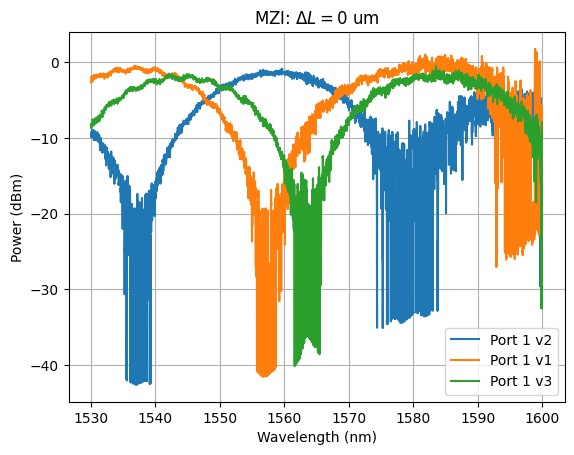

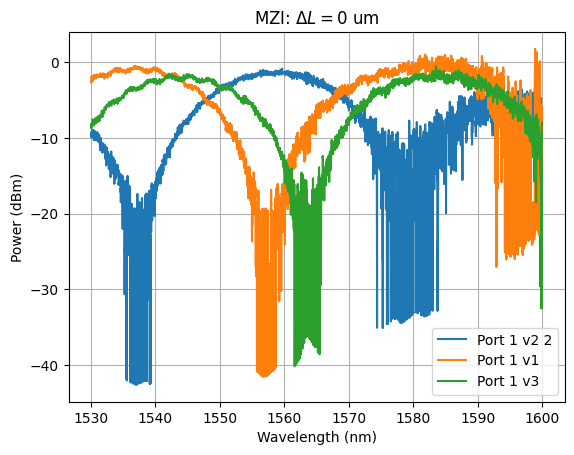

In [239]:
file_path= r"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/160MJ-0.4um/2\mzi_3_12 v2.txt"
wavelength_mzi3_12_v2_2, power_mzi3_12_v2_2 = open_file(file_path)
wavelength_mzi3_12_v2_2, power_mzi3_12_v2_2 = filter_wavelength(wavelength_mzi3_12_v2_2, power_mzi3_12_v2_2, wl_0, wl_1)

plt.plot(wavelength_mzi3_12_v2, power_mzi3_12_v2 - power_wg_v2, label='Port 1 v2')
plt.plot(wavelength_mzi3_12_v1, power_mzi3_12_v1 - power_wg_v1, label='Port 1 v1')
plt.plot(wavelength_mzi3_12_v3, power_mzi3_12_v3 - power_wg_v3, label='Port 1 v3')

plt.xlabel('Wavelength (nm)')   
plt.ylabel('Power (dBm)')
plt.title(r'MZI: $\Delta L = 0$ um')
plt.legend()
plt.grid()
plt.show()

plt.plot(wavelength_mzi3_12_v2_2, power_mzi3_12_v2 - power_wg_v2, label='Port 1 v2 2')
plt.plot(wavelength_mzi3_12_v1, power_mzi3_12_v1 - power_wg_v1, label='Port 1 v1')
plt.plot(wavelength_mzi3_12_v3, power_mzi3_12_v3 - power_wg_v3, label='Port 1 v3')

plt.xlabel('Wavelength (nm)')   
plt.ylabel('Power (dBm)')
plt.title(r'MZI: $\Delta L = 0$ um')
plt.legend()
plt.grid()
plt.show()

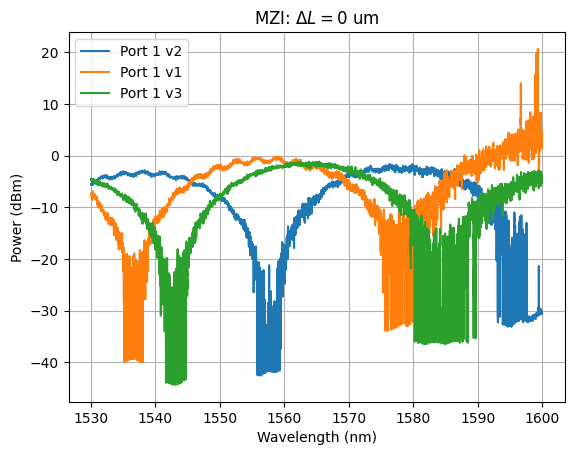

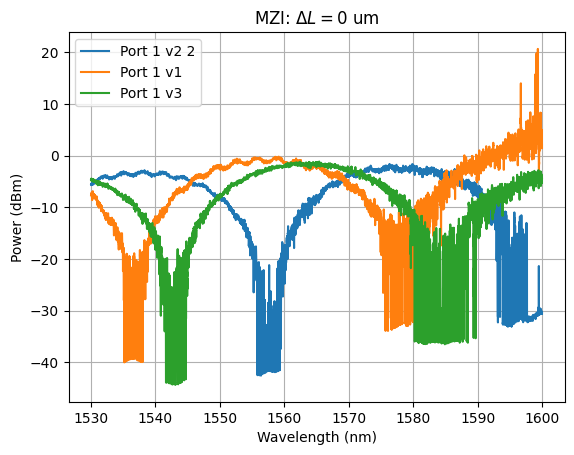

In [240]:
file_path= r"/home/arjoa/UPVfab/test_osa/data/MAGDALENA/V038_1094/160MJ-0.4um/2\mzi_3_11 v2.txt"
wavelength_mzi3_11_v2_2, power_mzi3_11_v2_2 = open_file(file_path)
wavelength_mzi3_11_v2_2, power_mzi3_11_v2_2 = filter_wavelength(wavelength_mzi3_11_v2_2, power_mzi3_11_v2_2, wl_0, wl_1)

plt.plot(wavelength_mzi3_11_v2, power_mzi3_11_v2 - power_wg_v2, label='Port 1 v2')
plt.plot(wavelength_mzi3_11_v1, power_mzi3_11_v1 - power_wg_v1, label='Port 1 v1')
plt.plot(wavelength_mzi3_11_v3, power_mzi3_11_v3 - power_wg_v3, label='Port 1 v3')

plt.xlabel('Wavelength (nm)')   
plt.ylabel('Power (dBm)')
plt.title(r'MZI: $\Delta L = 0$ um')
plt.legend()
plt.grid()
plt.show()

plt.plot(wavelength_mzi3_11_v2_2, power_mzi3_11_v2 - power_wg_v2, label='Port 1 v2 2')
plt.plot(wavelength_mzi3_11_v1, power_mzi3_11_v1 - power_wg_v1, label='Port 1 v1')
plt.plot(wavelength_mzi3_11_v3, power_mzi3_11_v3 - power_wg_v3, label='Port 1 v3')

plt.xlabel('Wavelength (nm)')   
plt.ylabel('Power (dBm)')
plt.title(r'MZI: $\Delta L = 0$ um')
plt.legend()
plt.grid()
plt.show()

# 160 MJ, -0.4 um

## Reference Waveguides

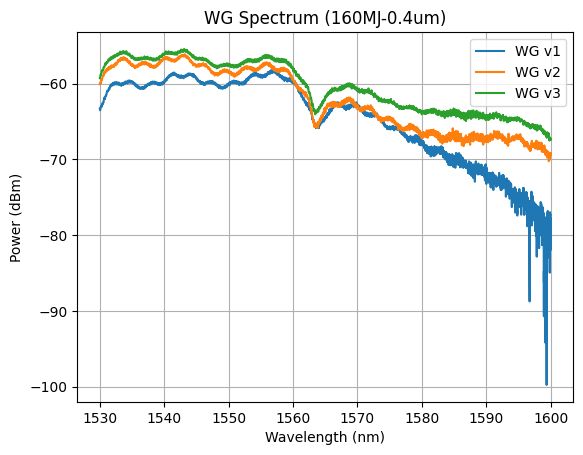

In [241]:
plt.plot(wavelength_wg_v1, power_wg_v1, label='WG v1')
plt.plot(wavelength_wg_v2, power_wg_v2, label='WG v2')
plt.plot(wavelength_wg_v3, power_wg_v3, label='WG v3')

plt.xlabel('Wavelength (nm)')   
plt.ylabel('Power (dBm)')
plt.title('WG Spectrum (160MJ-0.4um)')
plt.legend()
plt.grid()
plt.show()

## MZI ΔL = 0 um

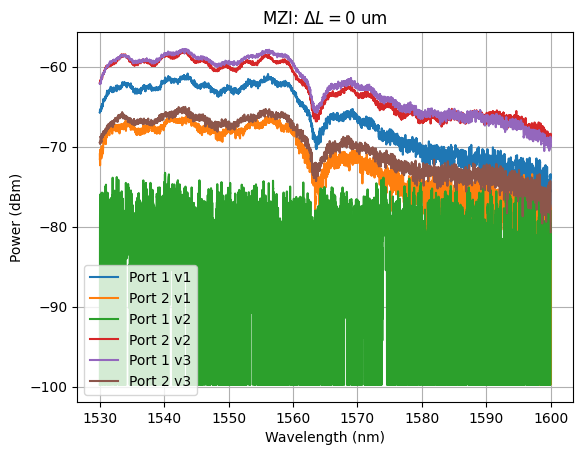

In [242]:
plt.plot(wavelength_mzi1_11_v1, power_mzi1_11_v1, label='Port 1 v1')
plt.plot(wavelength_mzi1_12_v1, power_mzi1_12_v1, label='Port 2 v1')
plt.plot(wavelength_mzi1_11_v2, power_mzi1_11_v2, label='Port 1 v2')
plt.plot(wavelength_mzi1_12_v2, power_mzi1_12_v2, label='Port 2 v2')
plt.plot(wavelength_mzi1_11_v3, power_mzi1_11_v3, label='Port 1 v3')
plt.plot(wavelength_mzi1_12_v3, power_mzi1_12_v3, label='Port 2 v3')

plt.xlabel('Wavelength (nm)')   
plt.ylabel('Power (dBm)')
plt.title(r'MZI: $\Delta L = 0$ um')
plt.legend()
plt.grid()
plt.show()

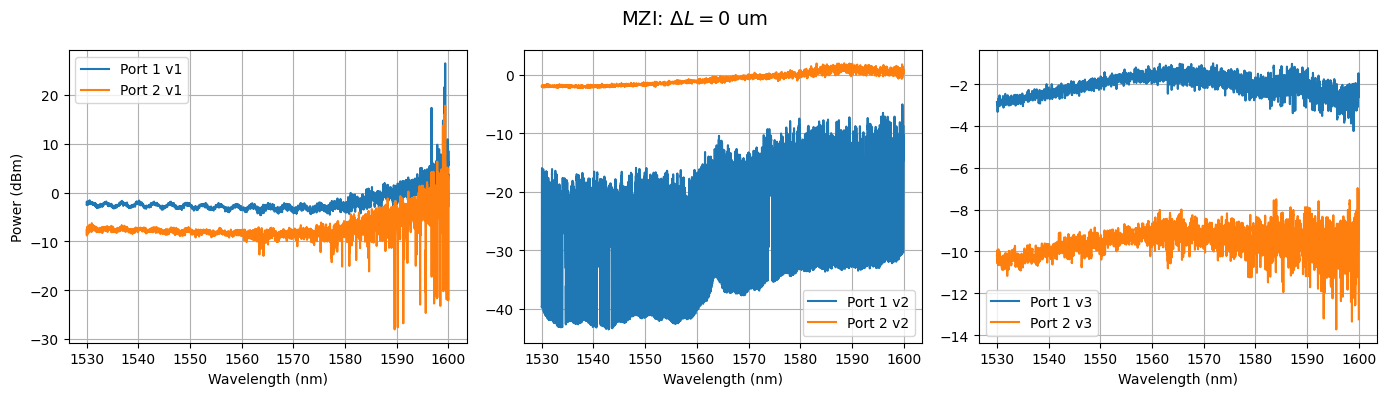

In [243]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4))

axs[0].plot(wavelength_mzi1_11_v1, power_mzi1_11_v1 - power_wg_v1, label='Port 1 v1')
axs[0].plot(wavelength_mzi1_12_v1, power_mzi1_12_v1 - power_wg_v1, label='Port 2 v1')
axs[0].set_xlabel('Wavelength (nm)')
axs[0].set_ylabel('Power (dBm)')
axs[0].legend()
axs[0].grid()

axs[1].plot(wavelength_mzi1_11_v2, power_mzi1_11_v2 - power_wg_v2, label='Port 1 v2')
axs[1].plot(wavelength_mzi1_12_v2, power_mzi1_12_v2 - power_wg_v2, label='Port 2 v2')
axs[1].set_xlabel('Wavelength (nm)')
axs[1].legend()
axs[1].grid()

axs[2].plot(wavelength_mzi1_11_v3, power_mzi1_11_v3 - power_wg_v3, label='Port 1 v3')
axs[2].plot(wavelength_mzi1_12_v3, power_mzi1_12_v3 - power_wg_v3, label='Port 2 v3')
axs[2].set_xlabel('Wavelength (nm)')
axs[2].legend()
axs[2].grid()

plt.suptitle(r'MZI: $\Delta L = 0$ um', fontsize=14)
plt.tight_layout()
plt.show()

## MZI ΔL = 10 um

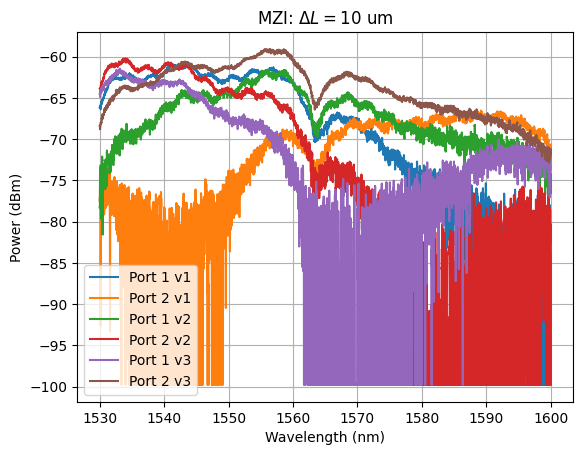

In [244]:
plt.plot(wavelength_mzi2_11_v1, power_mzi2_11_v1, label='Port 1 v1')
plt.plot(wavelength_mzi2_12_v1, power_mzi2_12_v1, label='Port 2 v1')
plt.plot(wavelength_mzi2_11_v2, power_mzi2_11_v2, label='Port 1 v2')
plt.plot(wavelength_mzi2_12_v2, power_mzi2_12_v2, label='Port 2 v2')
plt.plot(wavelength_mzi2_11_v3, power_mzi2_11_v3, label='Port 1 v3')
plt.plot(wavelength_mzi2_12_v3, power_mzi2_12_v3, label='Port 2 v3')

plt.xlabel('Wavelength (nm)')   
plt.ylabel('Power (dBm)')
plt.title(r'MZI: $\Delta L = 10$ um')
plt.legend()
plt.grid()
plt.show()

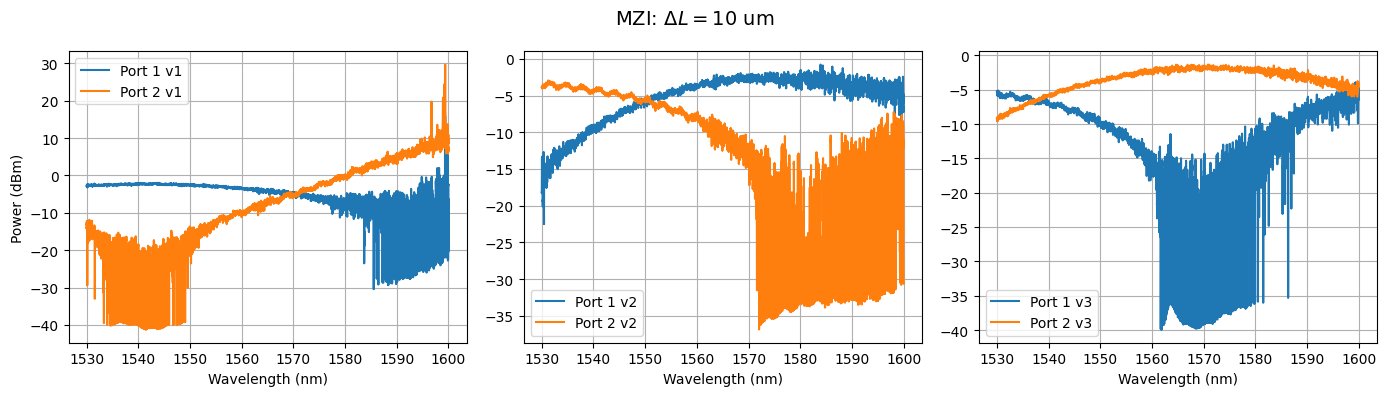

In [245]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4))

axs[0].plot(wavelength_mzi2_11_v1, power_mzi2_11_v1 - power_wg_v1, label='Port 1 v1')
axs[0].plot(wavelength_mzi2_12_v1, power_mzi2_12_v1 - power_wg_v1, label='Port 2 v1')
axs[0].set_xlabel('Wavelength (nm)')
axs[0].set_ylabel('Power (dBm)')
axs[0].legend()
axs[0].grid()

axs[1].plot(wavelength_mzi2_11_v2, power_mzi2_11_v2 - power_wg_v2, label='Port 1 v2')
axs[1].plot(wavelength_mzi2_12_v2, power_mzi2_12_v2 - power_wg_v2, label='Port 2 v2')
axs[1].set_xlabel('Wavelength (nm)')
axs[1].legend()
axs[1].grid()

axs[2].plot(wavelength_mzi2_11_v3, power_mzi2_11_v3 - power_wg_v3, label='Port 1 v3')
axs[2].plot(wavelength_mzi2_12_v3, power_mzi2_12_v3 - power_wg_v3, label='Port 2 v3')
axs[2].set_xlabel('Wavelength (nm)')
axs[2].legend()
axs[2].grid()

plt.suptitle(r'MZI: $\Delta L = 10$ um', fontsize=14)
plt.tight_layout()
plt.show()

## MZI ΔL = 30 um

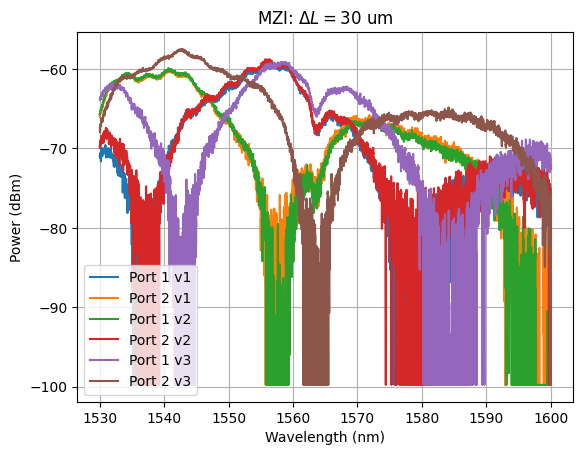

In [246]:
plt.plot(wavelength_mzi3_11_v1, power_mzi3_11_v1, label='Port 1 v1')
plt.plot(wavelength_mzi3_12_v1, power_mzi3_12_v1, label='Port 2 v1')
plt.plot(wavelength_mzi3_11_v2, power_mzi3_11_v2, label='Port 1 v2')
plt.plot(wavelength_mzi3_12_v2, power_mzi3_12_v2, label='Port 2 v2')
plt.plot(wavelength_mzi3_11_v3, power_mzi3_11_v3, label='Port 1 v3')
plt.plot(wavelength_mzi3_12_v3, power_mzi3_12_v3, label='Port 2 v3')

plt.xlabel('Wavelength (nm)')   
plt.ylabel('Power (dBm)')
plt.title(r'MZI: $\Delta L = 30$ um')
plt.legend()
plt.grid()
plt.show()

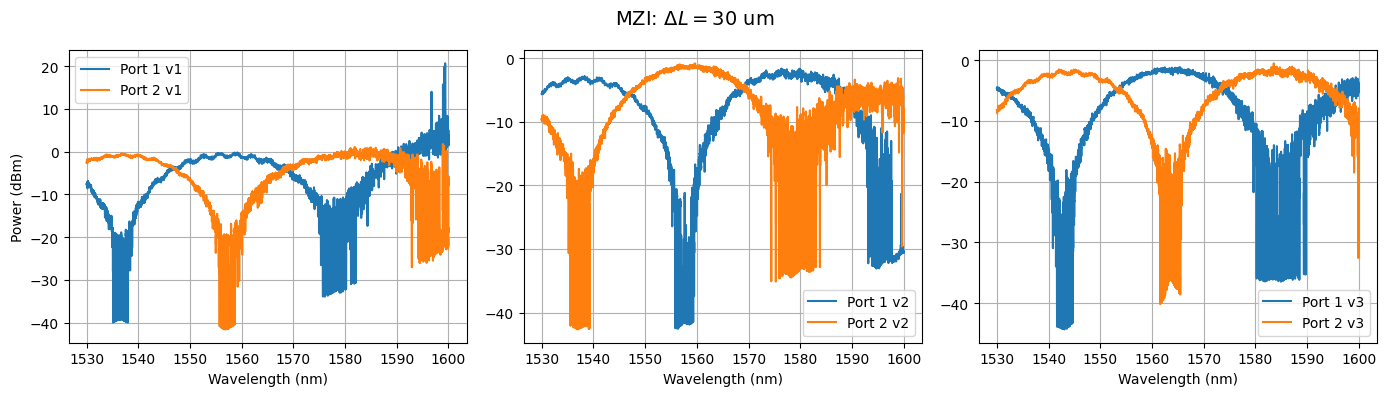

In [247]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4))

axs[0].plot(wavelength_mzi3_11_v1, power_mzi3_11_v1 - power_wg_v1, label='Port 1 v1')
axs[0].plot(wavelength_mzi3_12_v1, power_mzi3_12_v1 - power_wg_v1, label='Port 2 v1')
axs[0].set_xlabel('Wavelength (nm)')
axs[0].set_ylabel('Power (dBm)')
axs[0].legend()
axs[0].grid()

axs[1].plot(wavelength_mzi3_11_v2, power_mzi3_11_v2 - power_wg_v2, label='Port 1 v2')
axs[1].plot(wavelength_mzi3_12_v2, power_mzi3_12_v2 - power_wg_v2, label='Port 2 v2')
axs[1].set_xlabel('Wavelength (nm)')
axs[1].legend()
axs[1].grid()

axs[2].plot(wavelength_mzi3_11_v3, power_mzi3_11_v3 - power_wg_v3, label='Port 1 v3')
axs[2].plot(wavelength_mzi3_12_v3, power_mzi3_12_v3 - power_wg_v3, label='Port 2 v3')
axs[2].set_xlabel('Wavelength (nm)')
axs[2].legend()
axs[2].grid()

plt.suptitle(r'MZI: $\Delta L = 30$ um', fontsize=14)
plt.tight_layout()
plt.show()

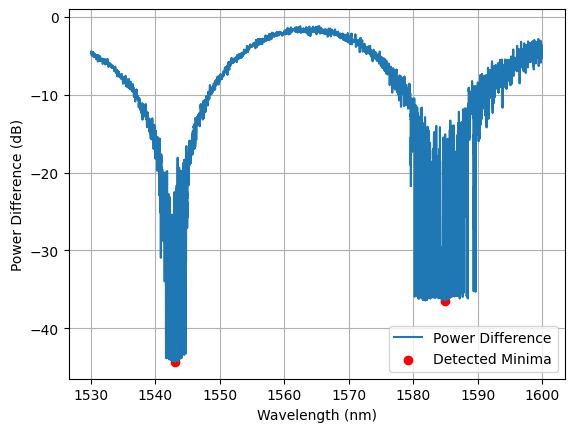

41.83999999999992
[1.89698033 2.00124687]
[ 6539 27459]
20920


In [248]:
# Processing parameters
threshold = 3
separation = 30
dL = 30e-6

fsr_v3, ng_v3, indices_v3, idx_distance_v3 = calculate_FSR(wavelength_mzi3_11_v3, power_mzi3_11_v3, power_wg_v3, threshold, separation, dL, plot=True)

print(fsr_v3)
print(ng_v3)
print(indices_v3)
print(idx_distance_v3)

FSR = 40.37 nm
ng = [1.97412418 2.07846103]


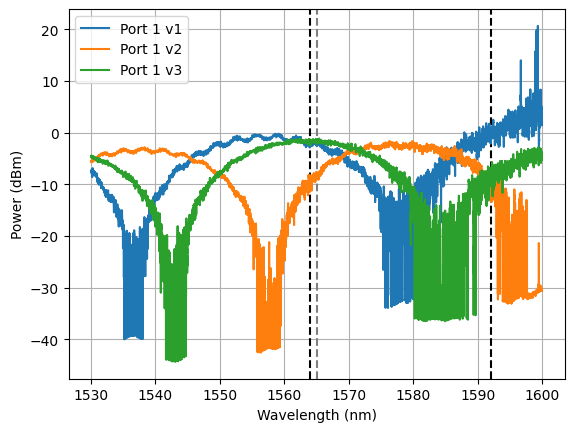

In [249]:
# Calculate FSR and group index
fsr_v1, ng_v1, indices_v1, idx_distance_v1 = calculate_FSR(wavelength_mzi3_11_v1, power_mzi3_11_v1, power_wg_v1, threshold, separation, dL, plot=False)
fsr_v2, ng_v2, indices_v2, idx_distance_v2 = calculate_FSR(wavelength_mzi3_11_v2, power_mzi3_11_v2, power_wg_v2, threshold, separation, dL, plot=False)
fsr_v3, ng_v3, indices_v3, idx_distance_v3 = calculate_FSR(wavelength_mzi3_11_v3, power_mzi3_11_v3, power_wg_v3, threshold, separation, dL, plot=False)

fsr_mean = np.mean([fsr_v1, fsr_v2, fsr_v3])
ng_mean = mean_array([ng_v1, ng_v2, ng_v3])

print(f"FSR = {fsr_mean:.2f} nm")
print(f"ng = {ng_mean}")

for i in range(len(indices_v3)):
    idx = indices_v3[i] - idx_distance_v3//2

    if idx < len(wavelength_mzi3_11_v3):
        plt.axvline(wavelength_mzi3_11_v3[indices_v3[i] - idx_distance_v3//2], color='black', linestyle='--')

indices = mean_array([indices_v1, indices_v2, indices_v3]).astype(int)
idx_distance = mean_array([idx_distance_v1, idx_distance_v2, idx_distance_v3]).astype(int)

for i in range(len(indices)):
    idx = indices[i]+idx_distance//2

    if idx < len(wavelength_mzi3_11_v1):
        plt.axvline(wavelength_mzi3_11_v1[indices[i] + idx_distance//2], color='gray', linestyle='--')

plt.plot(wavelength_mzi3_11_v1, power_mzi3_11_v1 - power_wg_v1, label='Port 1 v1')
plt.plot(wavelength_mzi3_11_v2, power_mzi3_11_v2 - power_wg_v2, label='Port 1 v2')
plt.plot(wavelength_mzi3_11_v3, power_mzi3_11_v3 - power_wg_v3, label='Port 1 v3')

plt.xlabel('Wavelength (nm)')
plt.ylabel('Power (dBm)')
plt.legend()
plt.grid()
plt.show()

## MZI ΔL = 50 um

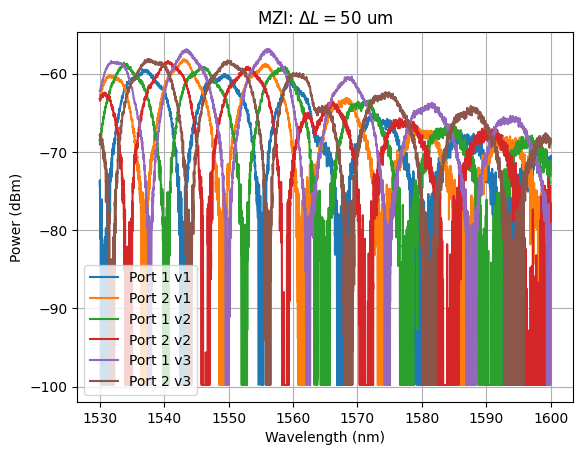

In [250]:
plt.plot(wavelength_mzi4_11_v1, power_mzi4_11_v1, label='Port 1 v1')
plt.plot(wavelength_mzi4_12_v1, power_mzi4_12_v1, label='Port 2 v1')
plt.plot(wavelength_mzi4_11_v2, power_mzi4_11_v2, label='Port 1 v2')
plt.plot(wavelength_mzi4_12_v2, power_mzi4_12_v2, label='Port 2 v2')
plt.plot(wavelength_mzi4_11_v3, power_mzi4_11_v3, label='Port 1 v3')
plt.plot(wavelength_mzi4_12_v3, power_mzi4_12_v3, label='Port 2 v3')

plt.xlabel('Wavelength (nm)')   
plt.ylabel('Power (dBm)')
plt.title(r'MZI: $\Delta L = 50$ um')
plt.legend()
plt.grid()
plt.show()

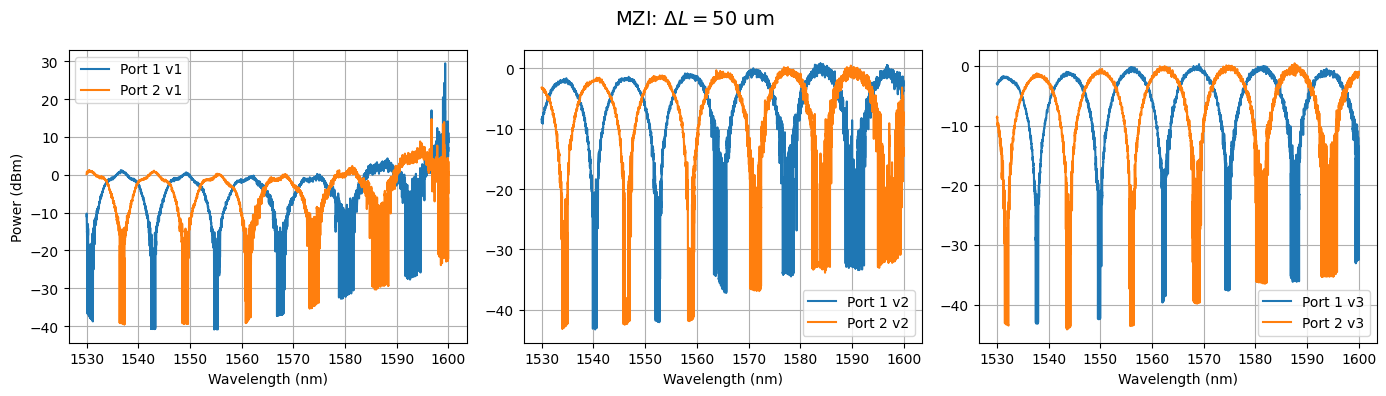

In [251]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4))

axs[0].plot(wavelength_mzi4_11_v1, power_mzi4_11_v1 - power_wg_v1, label='Port 1 v1')
axs[0].plot(wavelength_mzi4_12_v1, power_mzi4_12_v1 - power_wg_v1, label='Port 2 v1')
axs[0].set_xlabel('Wavelength (nm)')
axs[0].set_ylabel('Power (dBm)')
axs[0].legend()
axs[0].grid()

axs[1].plot(wavelength_mzi4_11_v2, power_mzi4_11_v2 - power_wg_v2, label='Port 1 v2')
axs[1].plot(wavelength_mzi4_12_v2, power_mzi4_12_v2 - power_wg_v2, label='Port 2 v2')
axs[1].set_xlabel('Wavelength (nm)')
axs[1].legend()
axs[1].grid()

axs[2].plot(wavelength_mzi4_11_v3, power_mzi4_11_v3 - power_wg_v3, label='Port 1 v3')
axs[2].plot(wavelength_mzi4_12_v3, power_mzi4_12_v3 - power_wg_v3, label='Port 2 v3')
axs[2].set_xlabel('Wavelength (nm)')
axs[2].legend()
axs[2].grid()

plt.suptitle(r'MZI: $\Delta L = 50$ um', fontsize=14)
plt.tight_layout()
plt.show()

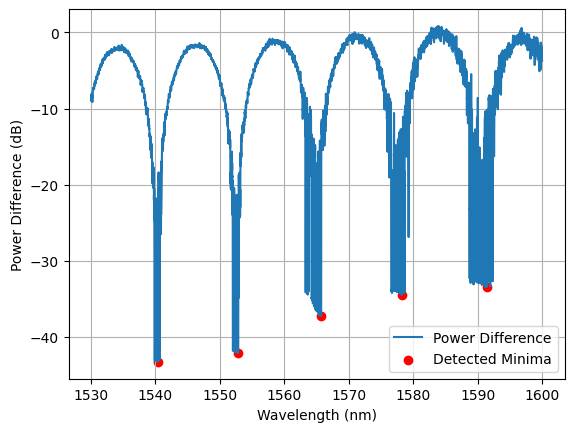

12.777000000000044
[3.71383846 3.77394204 3.83709605 3.89882718 3.9643783 ]
[ 5160 11367 17836 24108 30714]
6388


In [252]:
# Processing parameters
threshold = 3
separation = 10
dL = 50e-6

fsr_v1, ng_v1, indices_v1, idx_distance_v1 = calculate_FSR(wavelength_mzi4_11_v2, power_mzi4_11_v2, power_wg_v2, threshold, separation, dL, plot=True)

print(fsr_v1)
print(ng_v1)
print(indices_v1)
print(idx_distance_v1)

FSR = 12.45 nm
ng = [3.7923208  3.85216297 3.9141348  3.97603863 4.04046715 4.14461496]


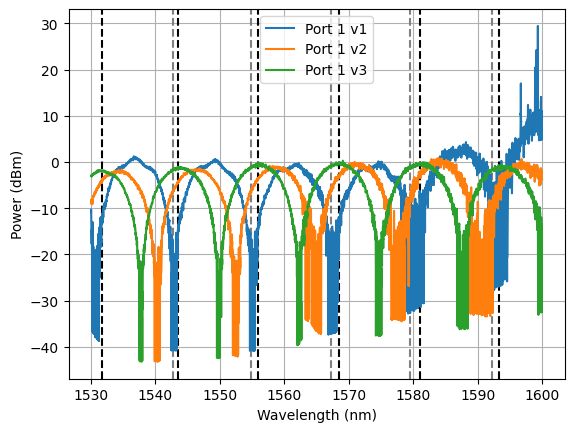

In [253]:
# Calculate FSR and group index
fsr_v1, ng_v1, indices_v1, idx_distance_v1 = calculate_FSR(wavelength_mzi4_11_v1, power_mzi4_11_v1, power_wg_v1, threshold, separation, dL, plot=False)
fsr_v2, ng_v2, indices_v2, idx_distance_v2 = calculate_FSR(wavelength_mzi4_11_v2, power_mzi4_11_v2, power_wg_v2, threshold, separation, dL, plot=False)
fsr_v3, ng_v3, indices_v3, idx_distance_v3 = calculate_FSR(wavelength_mzi4_11_v3, power_mzi4_11_v3, power_wg_v3, threshold, separation, dL, plot=False)

fsr_mean = np.mean([fsr_v1, fsr_v2, fsr_v3])
ng_mean = mean_array([ng_v1, ng_v2, ng_v3])

print(f"FSR = {fsr_mean:.2f} nm")
print(f"ng = {ng_mean}")

for i in range(len(indices_v3)):
    idx = indices_v3[i] - idx_distance_v3//2

    if idx < len(wavelength_mzi4_11_v3):
        plt.axvline(wavelength_mzi4_11_v3[indices_v3[i] - idx_distance_v3//2], color='black', linestyle='--')

indices = mean_array([indices_v1, indices_v2, indices_v3]).astype(int)
idx_distance = mean_array([idx_distance_v1, idx_distance_v2, idx_distance_v3]).astype(int)

for i in range(len(indices)):
    idx = indices[i]+idx_distance//2

    if idx < len(wavelength_mzi4_11_v1):
        plt.axvline(wavelength_mzi4_11_v1[indices[i] + idx_distance//2], color='gray', linestyle='--')

plt.plot(wavelength_mzi4_11_v1, power_mzi4_11_v1 - power_wg_v1, label='Port 1 v1')
plt.plot(wavelength_mzi4_11_v2, power_mzi4_11_v2 - power_wg_v2, label='Port 1 v2')
plt.plot(wavelength_mzi4_11_v3, power_mzi4_11_v3 - power_wg_v3, label='Port 1 v3')

plt.xlabel('Wavelength (nm)')
plt.ylabel('Power (dBm)')
plt.legend()
plt.grid()
plt.show()

## MZI ΔL = 100 um

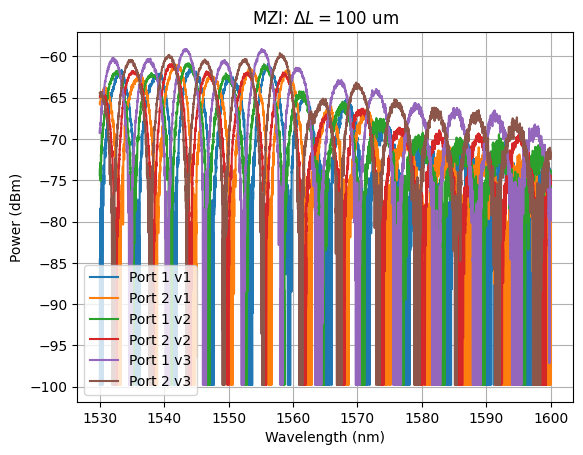

In [254]:
plt.plot(wavelength_mzi5_11_v1, power_mzi5_11_v1, label='Port 1 v1')
plt.plot(wavelength_mzi5_12_v1, power_mzi5_12_v1, label='Port 2 v1')
plt.plot(wavelength_mzi5_11_v2, power_mzi5_11_v2, label='Port 1 v2')
plt.plot(wavelength_mzi5_12_v2, power_mzi5_12_v2, label='Port 2 v2')
plt.plot(wavelength_mzi5_11_v3, power_mzi5_11_v3, label='Port 1 v3')
plt.plot(wavelength_mzi5_12_v3, power_mzi5_12_v3, label='Port 2 v3')

plt.xlabel('Wavelength (nm)')   
plt.ylabel('Power (dBm)')
plt.title(r'MZI: $\Delta L = 100$ um')
plt.legend()
plt.grid()
plt.show()

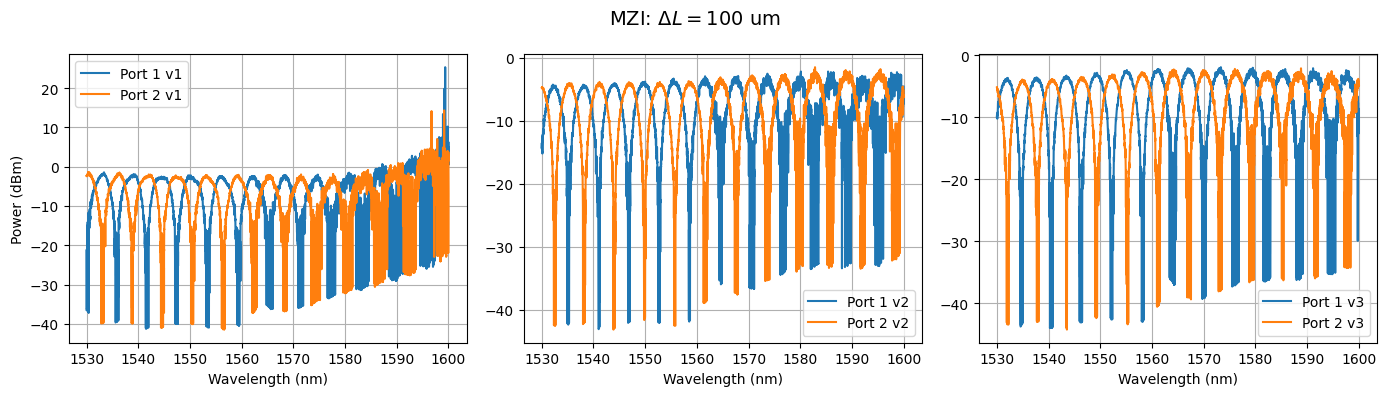

In [255]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4))

axs[0].plot(wavelength_mzi5_11_v1, power_mzi5_11_v1 - power_wg_v1, label='Port 1 v1')
axs[0].plot(wavelength_mzi5_12_v1, power_mzi5_12_v1 - power_wg_v1, label='Port 2 v1')
axs[0].set_xlabel('Wavelength (nm)')
axs[0].set_ylabel('Power (dBm)')
axs[0].legend()
axs[0].grid()

axs[1].plot(wavelength_mzi5_11_v2, power_mzi5_11_v2 - power_wg_v2, label='Port 1 v2')
axs[1].plot(wavelength_mzi5_12_v2, power_mzi5_12_v2 - power_wg_v2, label='Port 2 v2')
axs[1].set_xlabel('Wavelength (nm)')
axs[1].legend()
axs[1].grid()

axs[2].plot(wavelength_mzi5_11_v3, power_mzi5_11_v3 - power_wg_v3, label='Port 1 v3')
axs[2].plot(wavelength_mzi5_12_v3, power_mzi5_12_v3 - power_wg_v3, label='Port 2 v3')
axs[2].set_xlabel('Wavelength (nm)')
axs[2].legend()
axs[2].grid()

plt.suptitle(r'MZI: $\Delta L = 100$ um', fontsize=14)
plt.tight_layout()
plt.show()

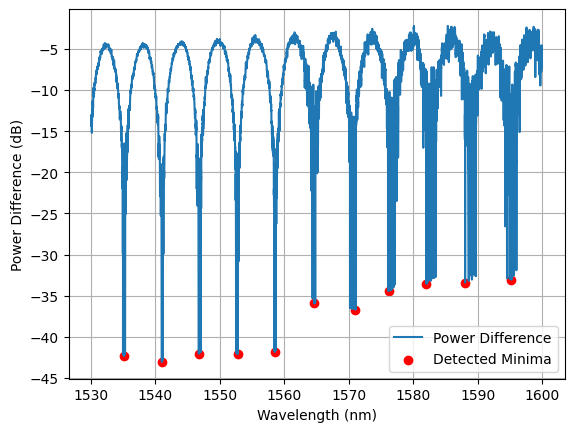

6.0131999999999834
[3.91908487 3.94911362 3.97849555 4.00948393 4.03946239 4.07126968
 4.10437205 4.13157742 4.16227115 4.19403973 4.23212407]
[ 2565  5500  8361 11367 14264 17326 20500 23099 26021 29034 32631]
3006


In [256]:
# Processing parameters
threshold = 3
separation = 5
dL = 100e-6

fsr_v1, ng_v1, indices_v1, idx_distance_v1 = calculate_FSR(wavelength_mzi5_11_v2, power_mzi5_11_v2, power_wg_v2, threshold, separation, dL, plot=True)

print(fsr_v1)
print(ng_v1)
print(indices_v1)
print(idx_distance_v1)

FSR = 5.97 nm
ng = [3.94078488 3.96951457 3.99969047 4.03074766 4.06207464 4.09362353
 4.12494374 4.15350382 4.18533242 4.21780784 4.25507068 4.29597393]


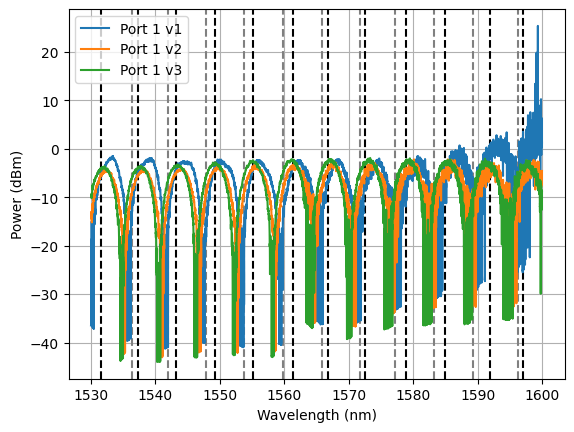

In [257]:
# Calculate FSR and group index
fsr_v1, ng_v1, indices_v1, idx_distance_v1 = calculate_FSR(wavelength_mzi5_11_v1, power_mzi5_11_v1, power_wg_v1, threshold, separation, dL, plot=False)
fsr_v2, ng_v2, indices_v2, idx_distance_v2 = calculate_FSR(wavelength_mzi5_11_v2, power_mzi5_11_v2, power_wg_v2, threshold, separation, dL, plot=False)
fsr_v3, ng_v3, indices_v3, idx_distance_v3 = calculate_FSR(wavelength_mzi5_11_v3, power_mzi5_11_v3, power_wg_v3, threshold, separation, dL, plot=False)

fsr_mean = np.mean([fsr_v1, fsr_v2, fsr_v3])
ng_mean = mean_array([ng_v1, ng_v2, ng_v3])

print(f"FSR = {fsr_mean:.2f} nm")
print(f"ng = {ng_mean}")

for i in range(len(indices_v3)):
    idx = indices_v3[i] - idx_distance_v3//2

    if idx < len(wavelength_mzi5_11_v3):
        plt.axvline(wavelength_mzi5_11_v3[indices_v3[i] - idx_distance_v3//2], color='black', linestyle='--')

indices = mean_array([indices_v1, indices_v2, indices_v3]).astype(int)
idx_distance = mean_array([idx_distance_v1, idx_distance_v2, idx_distance_v3]).astype(int)

for i in range(len(indices)):
    idx = indices[i]+idx_distance//2

    if idx < len(wavelength_mzi5_11_v1):
        plt.axvline(wavelength_mzi5_11_v1[indices[i] + idx_distance//2], color='gray', linestyle='--')

plt.plot(wavelength_mzi5_11_v1, power_mzi5_11_v1 - power_wg_v1, label='Port 1 v1')
plt.plot(wavelength_mzi5_11_v2, power_mzi5_11_v2 - power_wg_v2, label='Port 1 v2')
plt.plot(wavelength_mzi5_11_v3, power_mzi5_11_v3 - power_wg_v3, label='Port 1 v3')

plt.xlabel('Wavelength (nm)')
plt.ylabel('Power (dBm)')
plt.legend()
plt.grid()
plt.show()